# ROC Curve
> diabetes.csv

In [41]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
df = pd.read_csv('../../DATASETS/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# features and target
x = df.iloc[:, 0:-1]
y = df.iloc[:,-1]

In [5]:
# data split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [8]:
# model train
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
y_Pred = lr.predict(x_test)

In [11]:
# calculating probabilities
y_prob = lr.predict_proba(x_test)[:,1]
y_prob # probability of being diabetic.

array([0.27587183, 0.1884486 , 0.11448119, 0.16353908, 0.47152653,
       0.44181233, 0.01545867, 0.66072946, 0.54147717, 0.77732173,
       0.25594377, 0.89735442, 0.33620965, 0.30301529, 0.08197806,
       0.38091826, 0.13935464, 0.0747971 , 0.86674148, 0.56141934,
       0.20840308, 0.07739258, 0.5396823 , 0.09458239, 0.53952407,
       0.88556205, 0.12432372, 0.03016236, 0.2515306 , 0.11580603,
       0.91113322, 0.87074608, 0.76538   , 0.83751541, 0.61663989,
       0.68330955, 0.96813958, 0.24362707, 0.51149939, 0.73610847,
       0.06983444, 0.59409063, 0.58366217, 0.32719165, 0.02759128,
       0.50240106, 0.63933322, 0.22534503, 0.36054658, 0.95629027,
       0.04889831, 0.6609797 , 0.81169303, 0.24551726, 0.09325747,
       0.04152086, 0.77816057, 0.00570382, 0.40861015, 0.75696237,
       0.74137318, 0.35194509, 0.19235735, 0.20491187, 0.0768791 ,
       0.62718981, 0.05091507, 0.73284887, 0.03691634, 0.71593163,
       0.67524919, 0.07016403, 0.18114697, 0.1142987 , 0.09115

In [18]:
# roc curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
thresholds[1:]

# for different threshold levels it gives tpr and fpr.

array([0.97115303, 0.96813958, 0.95629027, 0.90263387, 0.89735442,
       0.8009706 , 0.77816057, 0.77789903, 0.77732173, 0.73284887,
       0.72429261, 0.68330955, 0.67524919, 0.6609797 , 0.66072946,
       0.65558359, 0.64968103, 0.63933322, 0.61663989, 0.60579203,
       0.58366217, 0.55035801, 0.53952407, 0.53417051, 0.50298175,
       0.50240106, 0.42047109, 0.42020194, 0.40861015, 0.38091826,
       0.33904185, 0.32719165, 0.30301529, 0.30266849, 0.25732285,
       0.24069316, 0.22534503, 0.22515723, 0.20840308, 0.20491187,
       0.16353908, 0.14042343, 0.12822032, 0.12697401, 0.11448119,
       0.1142987 , 0.04152086, 0.04048241, 0.00417283])

In [20]:
# best threshold
# Youden's J statistic


# argmax means argument of the maximum.
# Instead of returning the maximum value, it returns the index where the maximum occurs.
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_threshold

np.float64(0.5503580074548324)

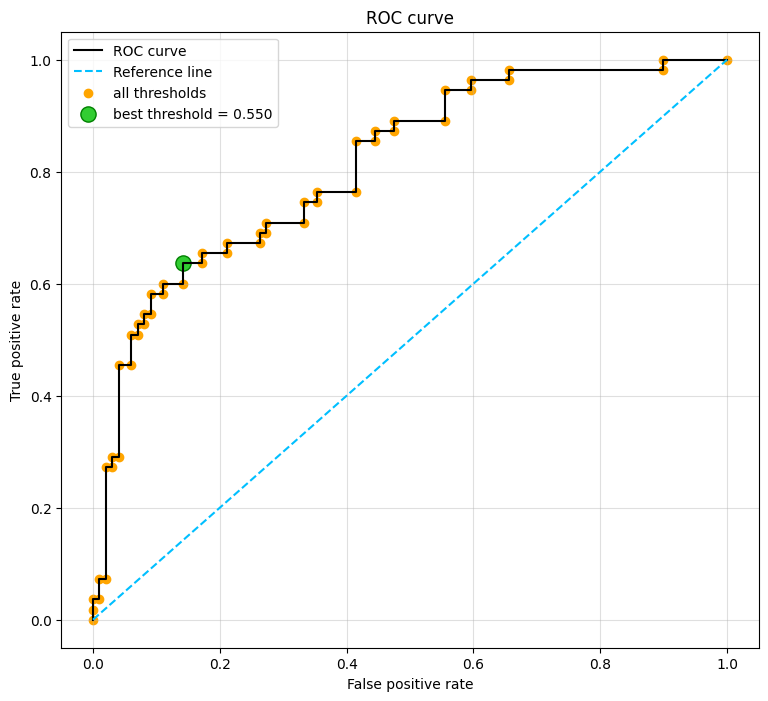

In [40]:
plt.figure(figsize=(9,8))
plt.plot(fpr, tpr, label = 'ROC curve', color = 'k')
plt.plot([0,1], [0,1], label = 'Reference line', ls = 'dashed', color = 'deepskyblue')
plt.scatter(fpr, tpr, label = 'all thresholds', color = 'orange')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], label = f'best threshold = {optimal_threshold:.3f}', s = 120, color = 'limegreen',edgecolors='green')


plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.grid(axis='both', alpha = 0.4)
plt.legend()
plt.show()

In [42]:
# roc auc score
print('AUC score: ',roc_auc_score(y_test, y_prob))

AUC score:  0.8128558310376492
